# 01 - Coleta e limpeza mínima

Passo a passo do slide: coletar → remover duplicatas exatas → corrigir tipos/unidades/strings → marcar valores impossíveis como faltando → descartar linhas totalmente ruins. **Nunca imputar nem remover outliers aqui.**

In [37]:
import pandas as pd
import numpy as np


In [ ]:
# Coleta dos dados: funciona no Colab e localmente
# 1) usa o arquivo se já existir (upload no Colab em /content, ou files/ no projeto)
# 2) senão baixa do GitHub (repositório público)
from pathlib import Path
import urllib.request

URL_DATASET = 'https://raw.githubusercontent.com/abdielpaulino/dxf-nesting-time/main/files/dataset.xlsx'
CANDIDATOS = [Path('/content/dataset.xlsx'), Path('files/dataset.xlsx'), Path('dataset.xlsx')]

caminho = next((p for p in CANDIDATOS if p.exists()), None)
if caminho is None:
    caminho = Path('dataset.xlsx')
    print('Baixando dataset do GitHub...')
    urllib.request.urlretrieve(URL_DATASET, caminho)

df_raw = pd.read_excel(caminho, sheet_name='Matriz_Completa')   # cópia intacta dos dados brutos
df = df_raw.copy()
print(f'Lido de: {caminho} -> {df.shape[0]:,} linhas x {df.shape[1]} colunas')
df.head(3)

In [ ]:
# Tirando duplicadas

n_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f'{n_dup} duplicatas exatas removidas -> {len(df):,} linhas')

In [ ]:
COLS_TEXTO = ['Material', 'Espessura', 'Gás Auxiliar', 'Tipo Bocal', 'Tipo de Acabamento', 'Plano Desenho']
COLS_NUM = [
    'Potência Laser (W)', 'Pressão Gás (bar)', 'Velocidade Corte (m/min)', 'Posição Foco (mm)',
    'Diâmetro Bocal (mm)', 'Distância Bocal (mm)', 'Perimetro (mm)',
    'Tempo Corte Estimado Segundos', 'Tempo Real Segundos',
    'Tempo Corte Estimado Minutos', 'Tempo Real Minutos', 'Diferença de Tempo Minutos',
]

for c in COLS_TEXTO:
    df[c] = (
        df[c].astype('string')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .replace('', pd.NA)
    )

# Texto numérico com vírgula decimal -> ponto, depois float
for c in COLS_NUM:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].astype('string').str.strip().str.replace(',', '.', regex=False)
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')

# Espessura numérica em mm: '3,18 mm (1/8")' -> 3.18
df['Espessura (mm)'] = pd.to_numeric(
    df['Espessura'].str.extract(r'^\s*([\d]+(?:[.,]\d+)?)\s*mm', expand=False).str.replace(',', '.'),
    errors='coerce',
).astype('float64')

df[COLS_TEXTO] = df[COLS_TEXTO].astype('category')
df.dtypes

In [ ]:
# Valores impossíveis -> NaN (limites físicos, não estatísticos; outlier plausível é mantido)

df[COLS_NUM + ['Espessura (mm)']] = df[COLS_NUM + ['Espessura (mm)']].replace([np.inf, -np.inf], np.nan)

POSITIVO_ESTRITO = [
    'Potência Laser (W)', 'Velocidade Corte (m/min)', 'Perimetro (mm)', 'Diâmetro Bocal (mm)', 'Espessura (mm)',
    'Tempo Corte Estimado Segundos', 'Tempo Real Segundos',
    'Tempo Corte Estimado Minutos', 'Tempo Real Minutos',
]
NAO_NEGATIVO = ['Pressão Gás (bar)', 'Distância Bocal (mm)']  # 'Diferença de Tempo Minutos' (real - estimado) pode ser negativa

impossiveis = {}
for c in POSITIVO_ESTRITO:
    mask = df[c] <= 0
    impossiveis[c] = int(mask.sum())
    df.loc[mask, c] = np.nan
for c in NAO_NEGATIVO:
    mask = df[c] < 0
    impossiveis[c] = int(mask.sum())
    df.loc[mask, c] = np.nan

pd.Series(impossiveis, name='impossíveis -> NaN')

In [ ]:
# Linhas totalmente ruins: sem alvo, sem desenho nem perímetro, ou todas as numéricas faltando

sem_alvo = df['Tempo Real Minutos'].isna()
sem_geometria = df['Plano Desenho'].isna() & df['Perimetro (mm)'].isna()
tudo_nan = df[COLS_NUM].isna().all(axis=1)

ruins = sem_alvo | sem_geometria | tudo_nan
df = df.loc[~ruins].reset_index(drop=True)
print(f'{ruins.sum()} linhas descartadas -> {len(df)} linhas')

In [41]:
df_limpo = df  # base limpa, sem imputação e sem remoção de outliers
df_limpo.head()

,Material,Espessura,Potência Laser (W),Gás Auxiliar,Pressão Gás (bar),Velocidade Corte (m/min),Posição Foco (mm),Tipo Bocal,Diâmetro Bocal (mm),Distância Bocal (mm),Tipo de Acabamento,Plano Desenho,Perimetro (mm),Tempo Corte Estimado Segundos,Tempo Real Segundos,Tempo Corte Estimado Minutos,Tempo Real Minutos,Diferença de Tempo Minutos,Espessura (mm)
0,Aço Carbono,"0,65 mm","1,500",O2 (Oxigênio),1.17,8.65,1.6,Duplo,1.2,0.8,Oxidação Controlada,n001,1.066e+04,73.96,113.2,1.233,1.887,0.6545,0.65
1,Aço Carbono,"0,65 mm","1,500",O2 (Oxigênio),1.17,8.65,1.6,Duplo,1.2,0.8,Oxidação Controlada,n002,2.727e+04,189.2,297.8,3.153,4.963,1.811,0.65
2,Aço Carbono,"0,65 mm","1,500",O2 (Oxigênio),1.17,8.65,1.6,Duplo,1.2,0.8,Oxidação Controlada,n003,5.05e+04,350.3,498.7,5.838,8.312,2.474,0.65
3,Aço Carbono,"0,65 mm","1,500",O2 (Oxigênio),1.17,8.65,1.6,Duplo,1.2,0.8,Oxidação Controlada,n004,1.401e+04,97.21,142,1.62,2.367,0.7467,0.65
4,Aço Carbono,"0,65 mm","1,500",O2 (Oxigênio),1.17,8.65,1.6,Duplo,1.2,0.8,Oxidação Controlada,n005,7.262e+04,503.7,784.3,8.396,13.07,4.675,0.65


# 02 - Split inicial

Split **por desenho** (`Plano Desenho`): cada desenho aparece em 406 linhas (uma por combinação de parâmetros), então o mesmo desenho não pode estar no treino e no teste. 80% dos desenhos para treino, 20% para teste. O teste não é usado para nenhuma decisão.

In [42]:
from sklearn.model_selection import GroupShuffleSplit

grupos = df_limpo['Plano Desenho'].astype(str)
idx_treino, idx_teste = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(df_limpo, groups=grupos))

df_treino = df_limpo.iloc[idx_treino].copy()
df_teste = df_limpo.iloc[idx_teste].copy()

assert not set(grupos.iloc[idx_treino]) & set(grupos.iloc[idx_teste]), 'desenho repetido entre treino e teste'
for nome, d in [('treino', df_treino), ('teste', df_teste)]:
    print(f'{nome:6s} linhas={len(d):>7,}  desenhos={d["Plano Desenho"].nunique():>4}  ({len(d)/len(df_limpo):.0%})')

treino linhas=141,288  desenhos= 348  (80%)
teste  linhas= 35,322  desenhos=  87  (20%)


# 03 - EDA (somente no treino)

Tudo daqui em diante usa `df_treino`. O `df_teste` não é lido.

In [43]:
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})
pd.set_option('display.float_format', lambda x: f'{x:,.4g}')

eda = df_treino.copy()
ALVO = 'Tempo Real Minutos'
PARAMS_NUM = ['Potência Laser (W)', 'Pressão Gás (bar)', 'Velocidade Corte (m/min)', 'Posição Foco (mm)',
              'Diâmetro Bocal (mm)', 'Distância Bocal (mm)', 'Espessura (mm)']
GEOMETRIA = ['Perimetro (mm)']
CATEGORICAS = ['Material', 'Gás Auxiliar', 'Tipo Bocal', 'Tipo de Acabamento']
# colunas que carregam o alvo ou a fórmula (analisadas na seção de leakage)
SUSPEITAS = ['Tempo Real Segundos', 'Tempo Corte Estimado Segundos', 'Tempo Corte Estimado Minutos', 'Diferença de Tempo Minutos']

# feature derivada candidata: tempo teórico = perímetro / velocidade
eda['tempo_teorico_min'] = eda['Perimetro (mm)'] / (eda['Velocidade Corte (m/min)'] * 1000)
eda['razao_real_teorico'] = eda[ALVO] / eda['tempo_teorico_min']
print(eda.shape, '| desenhos:', eda['Plano Desenho'].nunique())

(141288, 21) | desenhos: 348


## 03.01 Distribuições

In [45]:
NUM = PARAMS_NUM + GEOMETRIA + [ALVO, 'tempo_teorico_min']
eda[NUM].describe(percentiles=[.01, .25, .5, .75, .99]).T.assign(
    assimetria=eda[NUM].skew(), nunique=eda[NUM].nunique())

,count,mean,std,min,1%,25%,50%,75%,99%,max,assimetria,nunique
Potência Laser (W),1.413e+05,"6,754","4,134","1,500","1,500","3,000","6,000",1.2e+04,1.2e+04,1.2e+04,0.2356,4
Pressão Gás (bar),1.413e+05,12.77,7.446,0.35,0.4,1.15,15.85,18,24,25,-0.7622,137
Velocidade Corte (m/min),1.413e+05,21.1,29.43,0.69,0.99,4.94,9.86,24,150,195.7,2.922,376
Posição Foco (mm),1.413e+05,-0.9379,3.41,-15.2,-13.2,-1.9,-0.6,1.7,4.6,5,-1.249,101
Diâmetro Bocal (mm),1.413e+05,2.069,0.7336,1.2,1.2,1.5,2,2.5,4.5,4.5,1.307,8
Distância Bocal (mm),1.413e+05,0.5951,0.1258,0.5,0.5,0.5,0.5,0.8,0.8,0.8,0.8639,3
Espessura (mm),1.413e+05,6.341,6.166,0.65,0.65,2,4,9.52,25.4,25.4,1.341,29
Perimetro (mm),1.413e+05,"7,493",1.908e+04,89.96,123.3,555.7,"1,032","3,506",1.011e+05,1.318e+05,3.894,339
Tempo Real Minutos,1.413e+05,2.058,7.975,0.002118,0.08528,0.2144,0.354,0.9937,33.61,307.7,11.86,141288
tempo_teorico_min,1.413e+05,1.244,5.247,0.0004596,0.002829,0.03767,0.1214,0.4587,22.14,191,11.69,127299


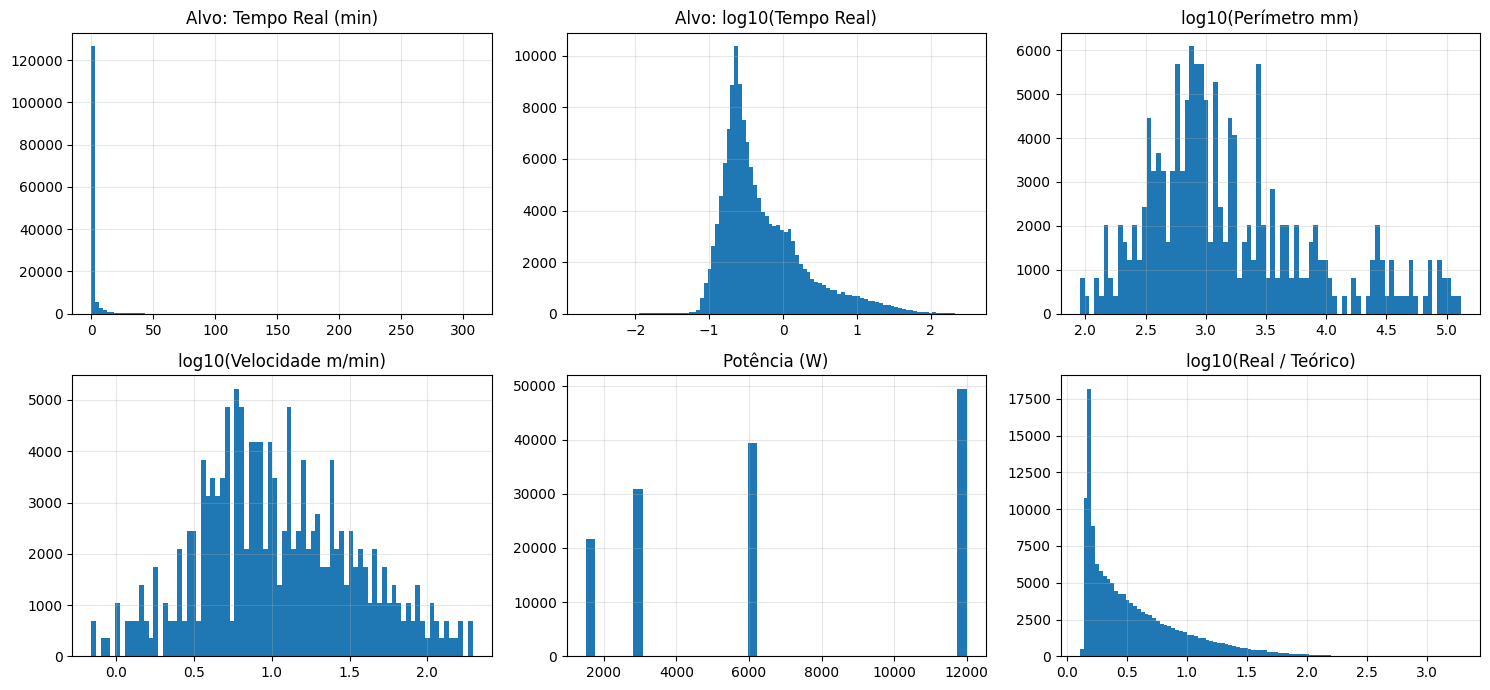

assimetria do alvo: 11.86  ->  em log: 1.26


In [46]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
ax = ax.ravel()
ax[0].hist(eda[ALVO], bins=100);                       ax[0].set_title('Alvo: Tempo Real (min)')
ax[1].hist(np.log10(eda[ALVO]), bins=100);             ax[1].set_title('Alvo: log10(Tempo Real)')
ax[2].hist(np.log10(eda['Perimetro (mm)']), bins=80);  ax[2].set_title('log10(Perímetro mm)')
ax[3].hist(np.log10(eda['Velocidade Corte (m/min)']), bins=80); ax[3].set_title('log10(Velocidade m/min)')
ax[4].hist(eda['Potência Laser (W)'], bins=40);        ax[4].set_title('Potência (W)')
ax[5].hist(np.log10(eda['razao_real_teorico']), bins=100); ax[5].set_title('log10(Real / Teórico)')
plt.tight_layout(); plt.show()
print(f"assimetria do alvo: {eda[ALVO].skew():.2f}  ->  em log: {np.log(eda[ALVO]).skew():.2f}")

**O que cada gráfico mostra**

1. **Alvo em minutos:** quase tudo se concentra na primeira barra, com cauda até ~300 min. No erro quadrático (RMSE), poucas peças enormes dominam e as 95% pequenas são ignoradas.
2. **`log10(Tempo Real)`:** o log resolve boa parte: pico em torno de −0,6 (≈0,25 min) e assimetria de 11,9 para 1,26. Esse deve ser o alvo.
3. **`log10(Perímetro)`:** serrilhado porque só existem 348 perímetros distintos (um por desenho, repetido 406 vezes). Há poucos desenhos grandes (20 mil a 130 mil mm), região onde o modelo tem menos exemplos.
4. **`log10(Velocidade)`:** também serrilhado (só 406 combinações de parâmetros), com formato de sino e cauda leve até ~200 m/min.
5. **Potência:** só 4 valores (1500, 3000, 6000 e 12000 W); na prática é uma variável categórica ordinal.
6. **`log10(Real / Teórico)`:** o real nunca é menor que 1,29× o teórico (perímetro ÷ velocidade). O pico está em ~1,5× e a cauda chega a ~1900×, o que sugere `real ≈ 1,5 × teórico + tempo fixo por peça`, com o tempo fixo dominando nas peças pequenas.

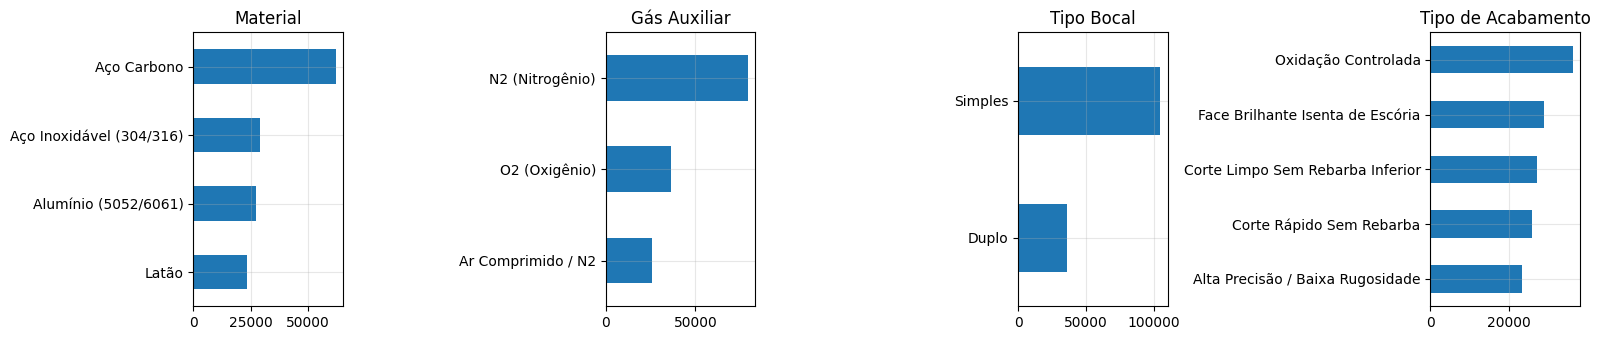

linhas por desenho: {'min': 406.0, '50%': 406.0, 'max': 406.0}
perímetro único por desenho: True


In [47]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))
for a, c in zip(ax, CATEGORICAS):
    eda[c].astype(str).value_counts().sort_values().plot.barh(ax=a); a.set_title(c); a.set_ylabel('')
plt.tight_layout(); plt.show()

# desenhos: cada um deve aparecer em ~406 linhas (uma por combinação de parâmetros)
linhas_por_desenho = eda.groupby('Plano Desenho', observed=True).size()
print('linhas por desenho:', linhas_por_desenho.describe()[['min', '50%', 'max']].to_dict())
print('perímetro único por desenho:', (eda.groupby('Plano Desenho', observed=True)['Perimetro (mm)'].nunique() == 1).all())

## 03.02 Balanceamento do alvo

Problema de **regressão**: não há classes para balancear. O equivalente é checar se o alvo está bem coberto pelas categorias.

In [44]:
# Cobertura do alvo por categoria (equivalente ao balanceamento de classes)
eda['faixa_alvo'] = pd.qcut(eda[ALVO], 5, labels=['q1 (menor)', 'q2', 'q3', 'q4', 'q5 (maior)'])
for c in ['Material', 'Gás Auxiliar']:
    display((pd.crosstab(eda[c], eda['faixa_alvo'], normalize='index') * 100).round(1))
display(eda.groupby('Material', observed=True)[ALVO].describe()[['count', 'mean', '50%', 'max']])

faixa_alvo,q1 (menor),q2,q3,q4,q5 (maior)
Material,,,,,
Alumínio (5052/6061),21.5,21.7,20.9,18.9,17
Aço Carbono,16.7,17.6,19.3,21.9,24.5
Aço Inoxidável (304/316),23.7,22.6,20,17.9,15.8
Latão,22.4,21.3,20.7,18.8,16.8


faixa_alvo,q1 (menor),q2,q3,q4,q5 (maior)
Gás Auxiliar,,,,,
Ar Comprimido / N2,28.3,25.2,18.2,15.8,12.5
N2 (Nitrogênio),22.6,21.9,20.5,18.5,16.5
O2 (Oxigênio),8.5,12.1,20.2,26.2,33


,count,mean,50%,max
Material,,,,
Alumínio (5052/6061),2.714e+04,1.488,0.322,71.96
Aço Carbono,6.194e+04,2.877,0.4343,307.7
Aço Inoxidável (304/316),2.888e+04,1.338,0.3022,67.64
Latão,2.332e+04,1.438,0.3178,58.99


# 04 - Modelagem (benchmark)

Quatro modelos, do mais simples ao mais completo:
1. Fórmula fixa (referência, sem treino)
2. Regressão linear simples
3. Regressão linear múltipla
4. Regressão polinomial múltipla

Comparação por **validação cruzada por desenho (`GroupKFold`) só no treino**. O teste é aberto uma única vez, no final.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

ALVO = 'Tempo Real Minutos'

def com_tempo_teorico(d):
    # tempo teórico (min) = perímetro (mm) / (velocidade (m/min) * 1000)
    d = d.copy()
    d['tempo_teorico_min'] = d['Perimetro (mm)'] / (d['Velocidade Corte (m/min)'] * 1000)
    return d

treino = com_tempo_teorico(df_treino)
teste = com_tempo_teorico(df_teste)

FEATURES_NUM = ['Potência Laser (W)', 'Pressão Gás (bar)', 'Velocidade Corte (m/min)', 'Posição Foco (mm)',
                'Diâmetro Bocal (mm)', 'Distância Bocal (mm)', 'Espessura (mm)', 'Perimetro (mm)', 'tempo_teorico_min']
FEATURES_CAT = ['Material', 'Gás Auxiliar']   # Tipo Bocal e Acabamento são função de Material + Gás (redundantes)

X_treino, y_treino = treino[FEATURES_NUM + FEATURES_CAT], treino[ALVO]
X_teste, y_teste = teste[FEATURES_NUM + FEATURES_CAT], teste[ALVO]
grupos_treino = treino['Plano Desenho'].astype(str)

cv = GroupKFold(n_splits=5)
resultados = {}

def metricas(y, pred):
    return {'MAE': mean_absolute_error(y, pred), 'RMSE': root_mean_squared_error(y, pred),
            'MAPE_%': mean_absolute_percentage_error(y, pred) * 100, 'R2': r2_score(y, pred)}

def avaliar_cv(nome, construir_modelo=None):
    # média das métricas nos 5 folds; None = fórmula fixa (não treina, só calcula)
    folds = []
    for i_tr, i_va in cv.split(X_treino, y_treino, groups=grupos_treino):
        if construir_modelo is None:
            pred = X_treino.iloc[i_va]['tempo_teorico_min']
        else:
            modelo = construir_modelo().fit(X_treino.iloc[i_tr], y_treino.iloc[i_tr])
            pred = modelo.predict(X_treino.iloc[i_va])
        folds.append(metricas(y_treino.iloc[i_va], pred))
    resultados[nome] = pd.DataFrame(folds).mean().to_dict()
    return pd.DataFrame([resultados[nome]], index=[nome])

## 04.01 Fórmula fixa

`tempo = perímetro / velocidade`. Não tem treino: é a referência que os modelos precisam superar.

In [ ]:
avaliar_cv('1. Fórmula fixa')

## 04.02 Regressão linear simples

Uma única variável: `tempo_teorico_min`.

In [ ]:
def linear_simples():
    return Pipeline([
        ('colunas', ColumnTransformer([('x', 'passthrough', ['tempo_teorico_min'])])),
        ('modelo', LinearRegression()),
    ])

avaliar_cv('2. Linear simples', linear_simples)

## 04.03 Regressão linear múltipla

Parâmetros de corte numéricos (padronizados) + Material e Gás (one-hot).

In [ ]:
def pre_processador(grau=None):
    if grau is None:
        numericas = StandardScaler()
    else:
        numericas = Pipeline([('escala', StandardScaler()), ('polinomio', PolynomialFeatures(degree=grau, include_bias=False))])
    return ColumnTransformer([
        ('num', numericas, FEATURES_NUM),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), FEATURES_CAT),
    ])

def linear_multipla():
    return Pipeline([('pre', pre_processador()), ('modelo', LinearRegression())])

avaliar_cv('3. Linear múltipla', linear_multipla)

## 04.04 Regressão polinomial múltipla (grau 2)

As mesmas variáveis, com quadrados e interações entre as numéricas.

In [ ]:
def polinomial_multipla():
    return Pipeline([('pre', pre_processador(grau=2)), ('modelo', LinearRegression())])

avaliar_cv('4. Polinomial múltipla (grau 2)', polinomial_multipla)

## 04.05 Comparação (validação cruzada no treino)

In [ ]:
pd.DataFrame(resultados).T

## 04.06 Avaliação final no teste

**Aberta uma única vez**, depois de definidos os modelos. Cada um é treinado no treino inteiro.

In [ ]:
modelos_finais = {'1. Fórmula fixa': None, '2. Linear simples': linear_simples,
                  '3. Linear múltipla': linear_multipla, '4. Polinomial múltipla (grau 2)': polinomial_multipla}
final = {}
for nome, construir in modelos_finais.items():
    if construir is None:
        pred = X_teste['tempo_teorico_min']
    else:
        pred = construir().fit(X_treino, y_treino).predict(X_teste)
    final[nome] = metricas(y_teste, pred)
pd.DataFrame(final).T